# Plotting tutorial

ProteoPy's `pr.pl` functions help you inspect sample coverage, missing
measurements, abundance distributions, and patterns across experimental
groups. This tutorial is an overview: each example asks a small question,
while the [plotting API](https://proteopy.readthedocs.io/en/latest/api/pl.html)
documents the full set of options.

**General plotting concepts**

An AnnData object stores samples in rows and proteins or peptides in columns.
`.X` contains measured intensities, `.obs` contains sample annotations, and
`.var` contains feature annotations. Sample labels come from
`.obs["sample_id"]`; protein labels come from `.var["protein_id"]`.
Detection counts describe **coverage**, whereas intensities describe
**abundance**. More detected proteins does not necessarily mean that the
proteins shared between samples are more abundant.

We use the protein-level erythropoiesis data from
[Karayel et al. (2020)](https://doi.org/10.15252/msb.20209813), covering five
differentiation stages. The loader downloads and caches the data on first
use. 


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import proteopy as pr

adata = pr.datasets.karayel_2020()
raw_intensities = adata.X.copy()  # Check preservation at the end.
adata

/opt/homebrew/Caskroom/miniforge/base/envs/proteopy1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 20 × 7758
    obs: 'sample_id', 'cell_type', 'replicate'
    var: 'protein_id', 'gene_id'

**Ordering samples and groups**

The intended ProteoPy convention is lexicographic ordering of string-coerced
labels for ordinary string/object annotations (`F1`, `F10`, `F2`), and
category order for categorical annotations. Store a biological sequence
as a pandas categorical rather than relying on the object's row order.
An explicit `order` takes precedence over metric sorting such as
`ascending`; otherwise the annotation order applies. Dendrograms impose
their own order when clustering is enabled.

<div class="admonition note">
<p class="admonition-title">Current ordering exceptions</p>
<p>Some functions still retain input order or sort by counts. In particular,
<code>n_proteins_per_sample</code> can retain row order within groups, and
<code>n_samples_per_category</code> sorts by counts by default. Their current
<code>order</code> handling can append unlisted items rather than subset
them. These examples pass complete explicit orders where needed; consult
each function's API before relying on subsetting.</p>
</div>

In [2]:
stage_order = ["Progenitor", "ProE&EBaso", "LBaso", "Poly", "Ortho"]
adata.obs["cell_type"] = pd.Categorical(
    adata.obs["cell_type"],
    categories=stage_order,
    ordered=True,
)
stage_colors = dict(zip(stage_order, plt.get_cmap("tab10").colors[:5]))
adata.obs[["sample_id", "cell_type", "replicate"]].head()

,sample_id,cell_type,replicate
LBaso_rep1,LBaso_rep1,LBaso,rep1
LBaso_rep2,LBaso_rep2,LBaso,rep2
LBaso_rep3,LBaso_rep3,LBaso,rep3
LBaso_rep4,LBaso_rep4,LBaso,rep4
Ortho_rep1,Ortho_rep1,Ortho,rep1


<div class="admonition note">
<p class="admonition-title">Missing values are not measured zeros</p>
<p>Intensity plots generally omit missing measurements; completeness and
detection plots count their absence. Measured zeros usually remain valid
observations unless a function's zero-handling option says otherwise.
The binary heatmap uses a detection threshold and needs an explicit
missing-value encoding; the correlation heatmap requires complete input
or a fill value. We explain those choices alongside their examples.
Missing sample annotations are a separate issue: functions may reject,
omit, or display them as a missing category. UpSet requires nonmissing
category labels.</p>
</div>

**Basic parameters**

Parameters are available where relevant, not uniformly across every function.

| Parameter | How to use it |
|---|---|
| `order_by` | Arrange individual samples by an annotation without pooling them. |
| `group_by` | Summarize or pool measurements by an annotation; the summary depends on the plot. |
| `order`, `ascending` | Request an explicit sequence or a metric-based sort; check function-specific subsetting behavior. |
| `color_scheme` | Use a palette or a label-to-color dictionary to keep groups recognizable. |
| `show` | Use `False` while composing a figure, then call `plt.show()`. |
| `ax` | Supply an Axes to compatible functions, or use `None` to create one. Some legacy functions instead take a boolean return flag. |
| `figsize` | Set a newly created figure's width and height in inches; size supplied figures with Matplotlib. |
| `save` | Pass a filename such as `"coverage.pdf"` to save a figure. |
| `print_stats` | Print the underlying summaries when supported. |
| `log_transform`, `z_transform` | Transform values for display; use only where supported and interpret the transformed scale. |
| `zero_to_na`, `fill_na` | Change missing-value handling locally; names and availability differ between functions. |
| `layer` | Select an alternate matrix only in functions that support it; all examples here use `.X`. |

**Arrange samples versus summarize groups**

In `n_proteins_per_sample`, `order_by` keeps one bar per sample, while
`group_by` shows the mean count per group with standard-deviation error
bars. These two arguments are mutually exclusive. This is not the number
of distinct proteins found anywhere in the group.

The two panels also demonstrate composition: create the figure, pass each
Axes explicitly, and display it once. Samples within each stage retain
their existing sequence in this implementation.


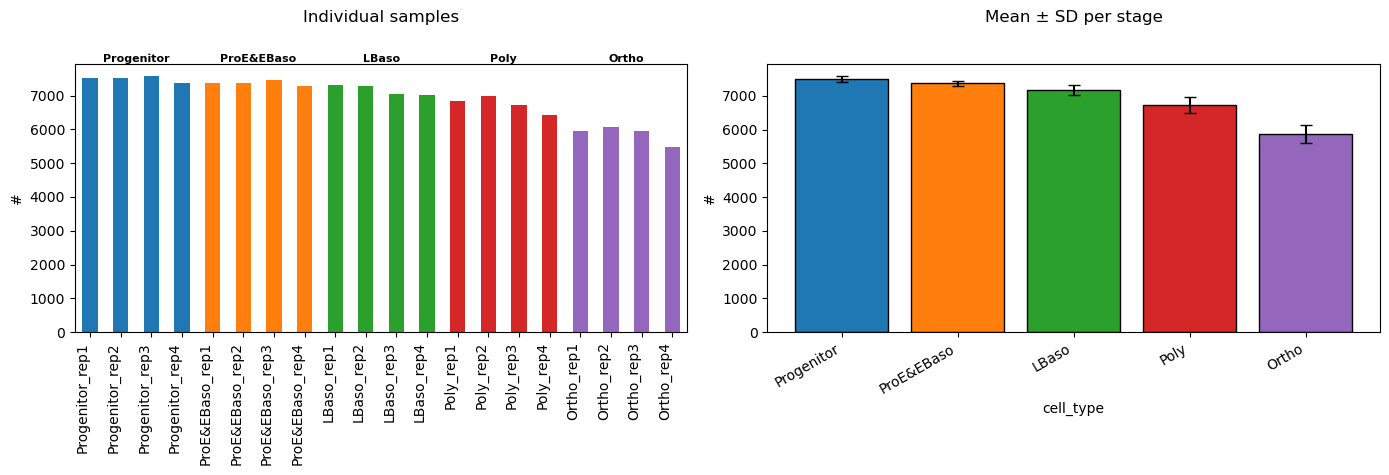

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pr.pl.n_proteins_per_sample(
    adata,
    order_by="cell_type",
    order=stage_order,
    color_scheme=stage_colors,
    title="",
    ax=axes[0],
    show=False,
)
pr.pl.n_proteins_per_sample(
    adata,
    group_by="cell_type",
    order=stage_order,
    color_scheme=stage_colors,
    title="",
    xlabel_rotation=30,
    ax=axes[1],
    show=False,
)
axes[0].set_title("Individual samples", pad=30)
axes[1].set_title("Mean ± SD per stage", pad=30)
fig.tight_layout()
plt.show()

**Two ways to work with an Axes**

When a function accepts an Axes object, it draws on and returns that same
object. Use `is` to check identity. This lets you customize labels or
combine plots with other Matplotlib artists.


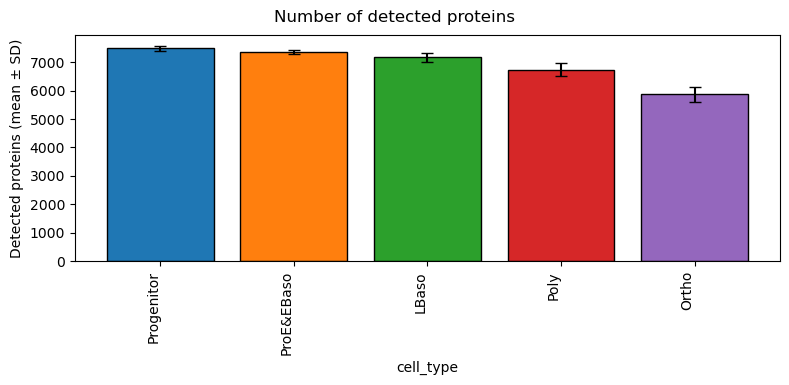

In [4]:
fig, supplied_ax = plt.subplots(figsize=(8, 4))
returned_ax = pr.pl.n_proteins_per_sample(
    adata,
    group_by="cell_type",
    order=stage_order,
    color_scheme=stage_colors,
    ax=supplied_ax,
    show=False,
)
assert returned_ax is supplied_ax
supplied_ax.set_ylabel("Detected proteins (mean ± SD)")
fig.tight_layout()
plt.show()

With `ax=None`, the function creates a new figure and returns its Axes.
That is a separate object, not the previously supplied Axes. Save a
customized figure with `returned_ax.figure.savefig("coverage.pdf")`.

The object-based interface below applies to `n_proteins_per_sample`.
For example, `intensity_hist`, `box`, and `sample_correlation_matrix`
currently use a boolean `ax` flag instead. UpSet returns a dictionary of
named axes and has no supplied-Axes argument.


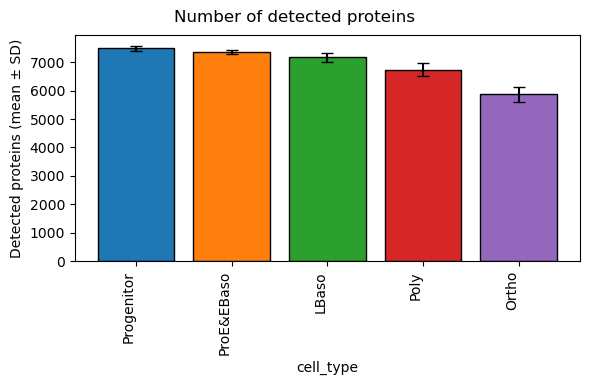

In [5]:
returned_ax = pr.pl.n_proteins_per_sample(
    adata,
    group_by="cell_type",
    order=stage_order,
    color_scheme=stage_colors,
    ax=None,
    show=False,
)
assert returned_ax is not supplied_ax
returned_ax.set_ylabel("Detected proteins (mean ± SD)")
returned_ax.figure.tight_layout()
plt.show()

## Protein level

The examples below use the same raw Karayel data. Protein identifiers can
represent protein groups; a plotted feature need not be a single gene.
These are exploratory plots, not evidence of statistical significance.


**`n_samples_per_category`**

Check that sample numbers are balanced across stages before comparing distributions. A balanced count does not by itself establish independent replication; interpret replicates using the study design.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.n_samples_per_category.html)


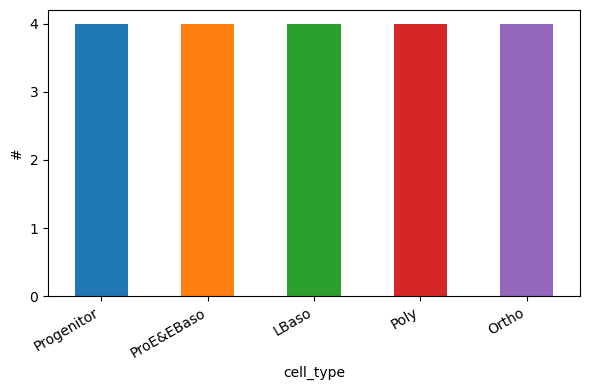

In [6]:
pr.pl.n_samples_per_category(
    adata,
    category_key="cell_type",
    order=stage_order,
    color_scheme=stage_colors,
    xlabel_rotation=30,
)

**`n_cat1_per_cat2_hist`**

Count distinct replicate labels per stage. This histogram summarizes how many stages have each replicate count; it does not identify the individual stages. `axis=0` selects observation annotations. All five stages have four replicate labels; an explicit bin range centers the single bar on four.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.n_cat1_per_cat2_hist.html)


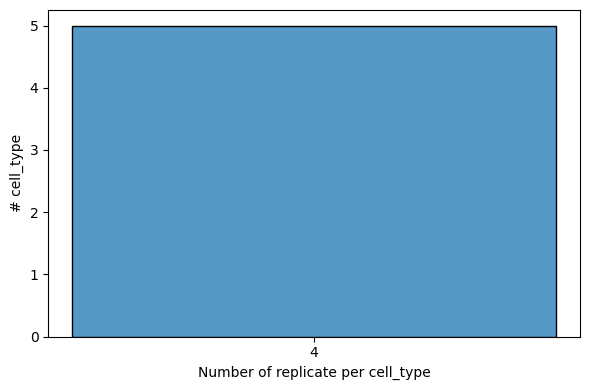

In [7]:
replicate_ax = pr.pl.n_cat1_per_cat2_hist(
    adata,
    first_category="replicate",
    second_category="cell_type",
    axis=0,
    bin_width=1,
    bin_range=(3.5, 4.5),
    show=False,
)

replicate_ax.set_xticks([4])
plt.show()

**`n_proteins_per_sample`**

Compare detection depth across samples to spot unusually low coverage. A nonmissing zero counts as measured unless `zero_to_na=True`. Here a complete sample order makes the lexicographic sequence explicit.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.n_proteins_per_sample.html)


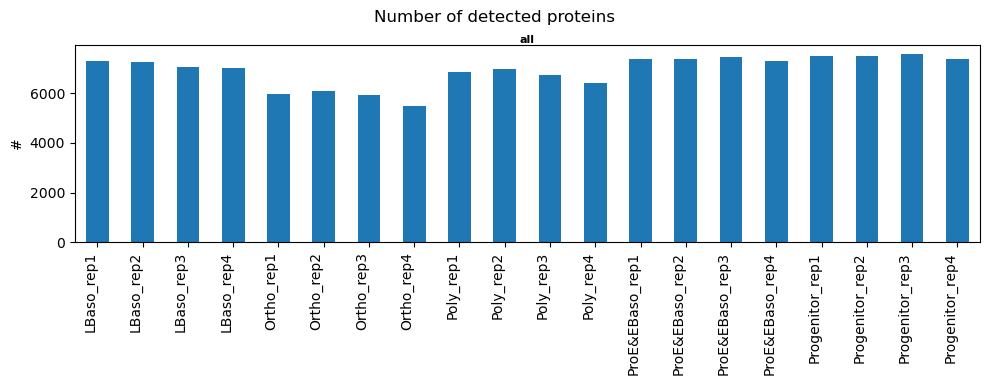

<Axes: ylabel='#'>

In [8]:
sample_order = sorted(adata.obs["sample_id"].astype(str))
pr.pl.n_proteins_per_sample(
    adata,
    order=sample_order,
    figsize=(10, 4),
)

`percentage=True` expresses coverage relative to all protein features in
this object, not to every protein in the organism. Grouped error bars
still describe between-sample variation in coverage.


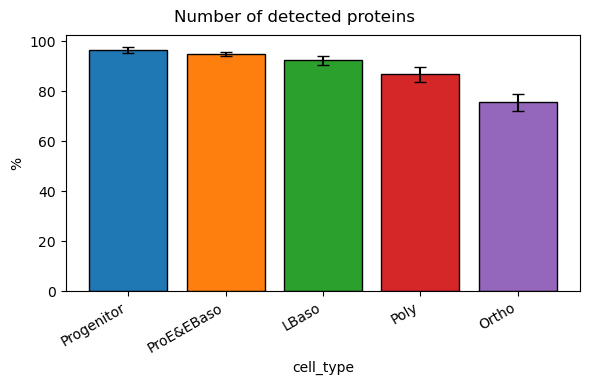

<Axes: xlabel='cell_type', ylabel='%'>

In [9]:
pr.pl.n_proteins_per_sample(
    adata,
    group_by="cell_type",
    order=stage_order,
    percentage=True,
    color_scheme=stage_colors,
    xlabel_rotation=30,
)

**`completeness_per_sample`**

Inspect the distribution of the fraction of measured proteins per sample. The histogram summarizes coverage but hides sample identities; use the preceding bar chart to identify individual low-coverage samples.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.completeness_per_sample.html)


Global:
 count   mean  median    std    min    max
    20 0.8927  0.9230 0.0803 0.7077 0.9751



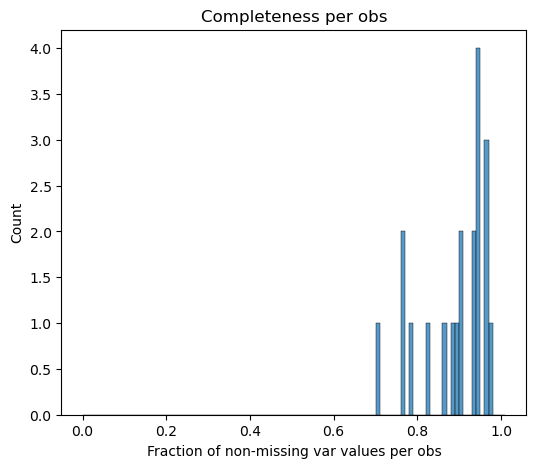

<Axes: title={'center': 'Completeness per obs'}, xlabel='Fraction of non-missing var values per obs', ylabel='Count'>

In [10]:
pr.pl.completeness_per_sample(adata, print_stats=True)

**`completeness_per_var`**

Ask how consistently proteins are measured across samples. Low completeness can reflect stage-specific detection as well as technical missingness. The generic `pr.pl.completeness(adata, axis=0)` provides the per-variable interface; `axis=1` selects samples.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.completeness_per_var.html)


Global:
 count   mean  median    std    min    max
  7758 0.8927  1.0000 0.2102 0.0000 1.0000



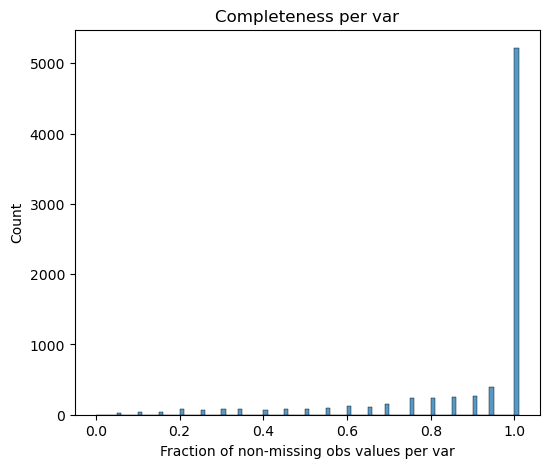

<Axes: title={'center': 'Completeness per var'}, xlabel='Fraction of non-missing obs values per var', ylabel='Count'>

In [11]:
pr.pl.completeness_per_var(adata, print_stats=True)

**`var_detected_by_cat_upset`**

Compare sets of detected proteins across stages. A protein is a *member* of a stage when it is detected (not missing) in enough samples of that stage; by default, one detection suffices (`min_count=1`). Each intersection bar counts proteins that are members of exactly the connected stages and no others. Side totals count all members of each stage. Proteins that meet no stage's threshold form their own intersection: the column with no filled dots (labelled “No category” by `print_stats=True`). With the default threshold, these are proteins never measured in any sample.

The stages come from the categorical order of `cell_type` set above; where they appear in the figure is decided by UpSetPlot. Measured zeros count as detections unless `zero_to_na=True`. The returned dictionary contains `matrix`, `intersections`, `totals`, and `shading` axes, all sharing one figure.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.var_detected_by_cat_upset.html)

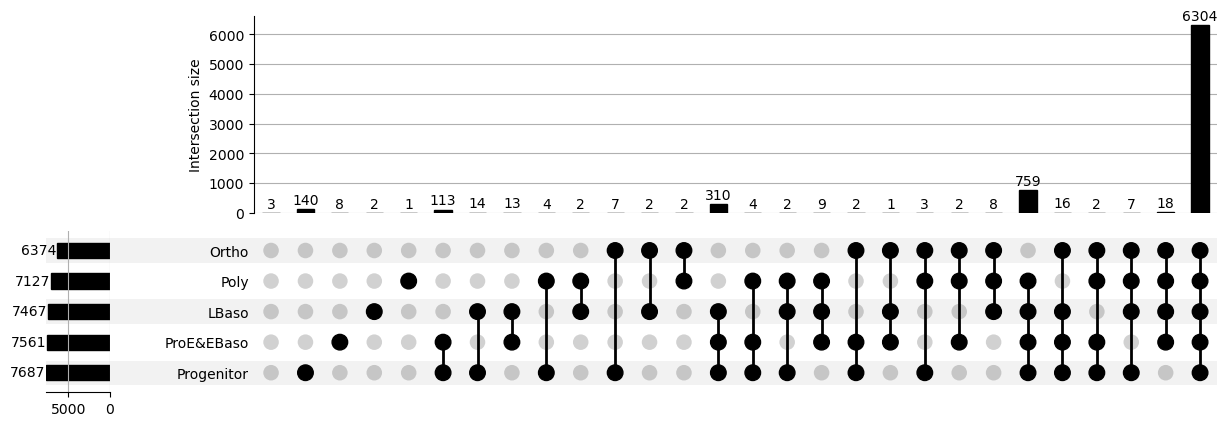

In [12]:
upset_axes = pr.pl.var_detected_by_cat_upset(
    adata,
    cat_key="cell_type",
    show=False,
)
plt.show()

A stricter threshold admits a protein to a stage only when it is measured
in **every sample** of that stage (`min_fraction=1.0`). This changes set
membership, so it changes the question the plot answers. Use `min_count`
for an absolute number of samples or `min_fraction` for a fraction of each
stage's samples; setting both raises an error. `print_stats=True` prints
the counts behind the bars.

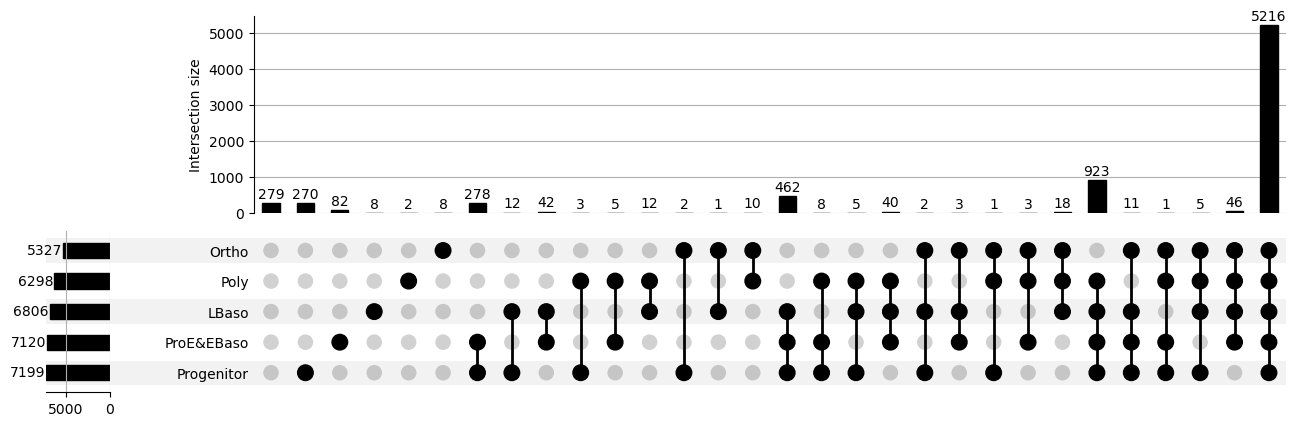

In [13]:
upset_axes = pr.pl.var_detected_by_cat_upset(
    adata,
    cat_key="cell_type",
    min_fraction=1.0,
    show=False,
)
plt.show()

**`intensity_hist`**

Inspect the abundance range and distribution shape across all measured sample–protein values. A log scale makes the long intensity tail readable. Here `log_transform=2` computes log2(intensity + 1) locally; missing values are omitted and the original matrix stays unchanged.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.intensity_hist.html)


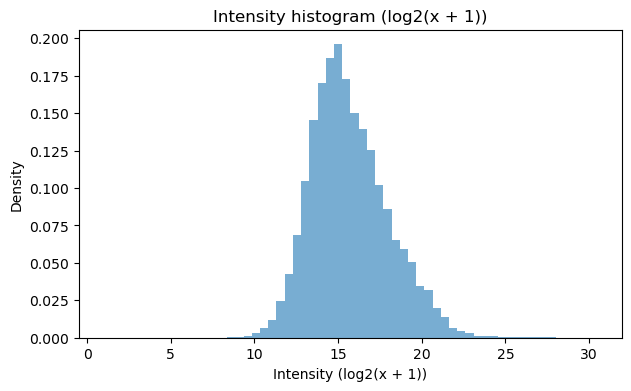

In [14]:
pr.pl.intensity_hist(adata, log_transform=2, bins=60)

**`intensity_box_per_sample`**

Compare abundance distributions between samples. Shifts may reflect biology or sample-level technical effects; this plot does not normalize them. Use the same log2(intensity + 1) display scale for each sample.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.intensity_box_per_sample.html)


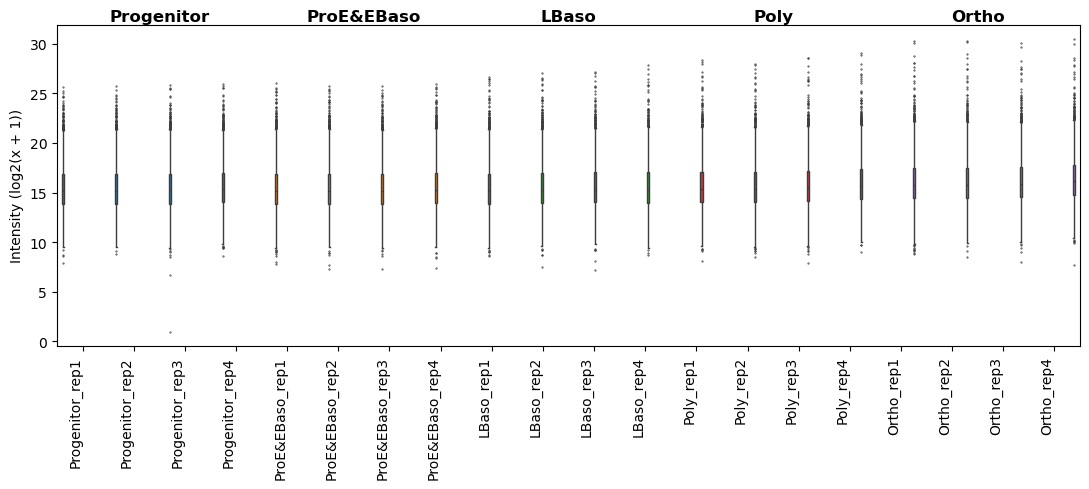

<Axes: ylabel='Intensity (log2(x + 1))'>

In [15]:
pr.pl.intensity_box_per_sample(
    adata,
    order_by="cell_type",
    order=stage_order,
    log_transform=2,
    ylabel="Intensity (log2(x + 1))",
    color_scheme=stage_colors,
    figsize=(11, 5),
)

**`abundance_rank`**

View the dynamic range of mean protein abundance across samples. Averages ignore missing values, so proteins can have different numbers of contributing measurements. Rank order is determined by abundance, not by categorical labels. `input_space="linear"` states that the input is raw intensity; the function applies its own log10 display transformation.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.abundance_rank.html)


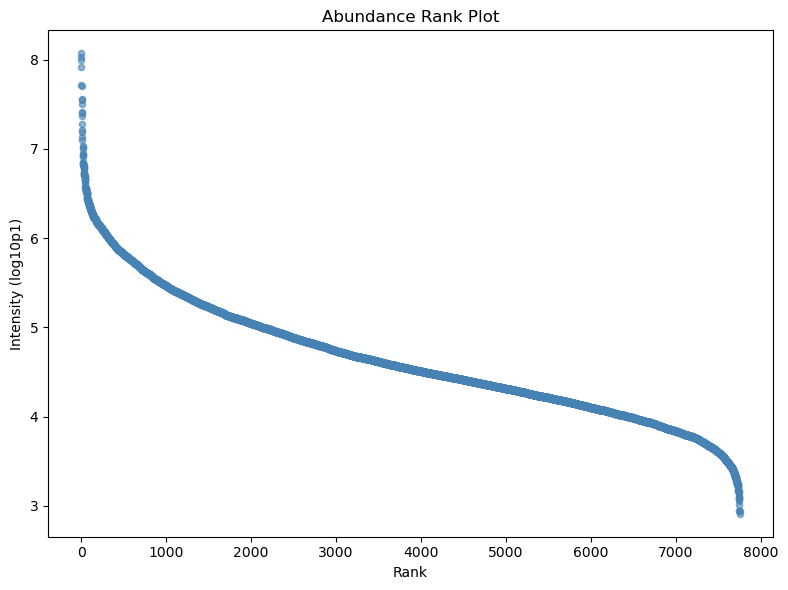

In [16]:
pr.pl.abundance_rank(
    adata,
    summary_method="average",
    input_space="linear",
    log_transform=10,
)

**`box`**

Inspect a single protein across stages, retaining individual sample points to show how many measurements support each box. We choose the first fully measured, nonconstant protein in lexicographic protein-ID order for a reproducible illustration, not as a biological finding. This display selection does not filter the loaded object.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.box.html)


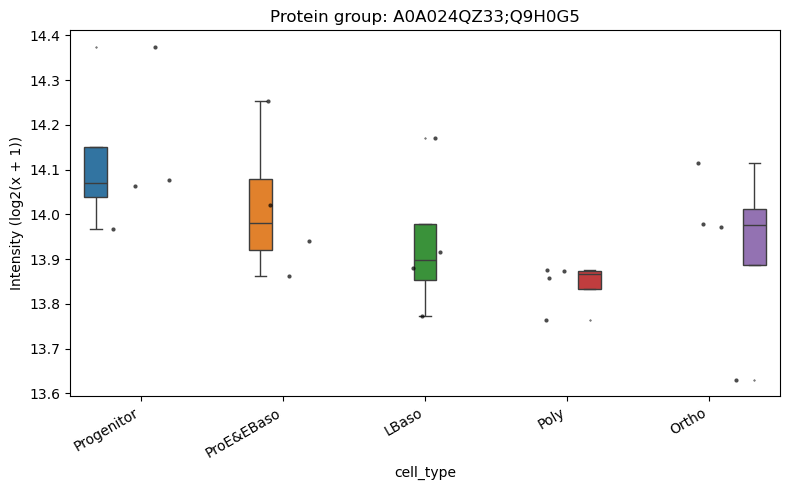

In [17]:
complete = np.isfinite(adata.X).all(axis=0)
variable = np.zeros(adata.n_vars, dtype=bool)
variable[complete] = np.ptp(adata.X[:, complete], axis=0) > 0
complete_protein_ids = sorted(
    adata.var.loc[complete & variable, "protein_id"].astype(str)
)
example_protein = complete_protein_ids[0]
pr.pl.box(
    adata,
    keys=example_protein,
    group_by="cell_type",
    order=stage_order,
    log_transform=2,
    show_points=True,
    color_scheme=stage_colors,
    title=f"Protein group: {example_protein}",
    xlabel_rotation=30,
)

**`cv_by_group`**

Compare the distribution of per-protein coefficients of variation within stages. CV is the standard deviation divided by the mean, computed on raw linear intensities. It is sensitive to low means and does not distinguish technical from biological variability. Requiring at least three measured samples makes the inclusion rule explicit.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.cv_by_group.html)


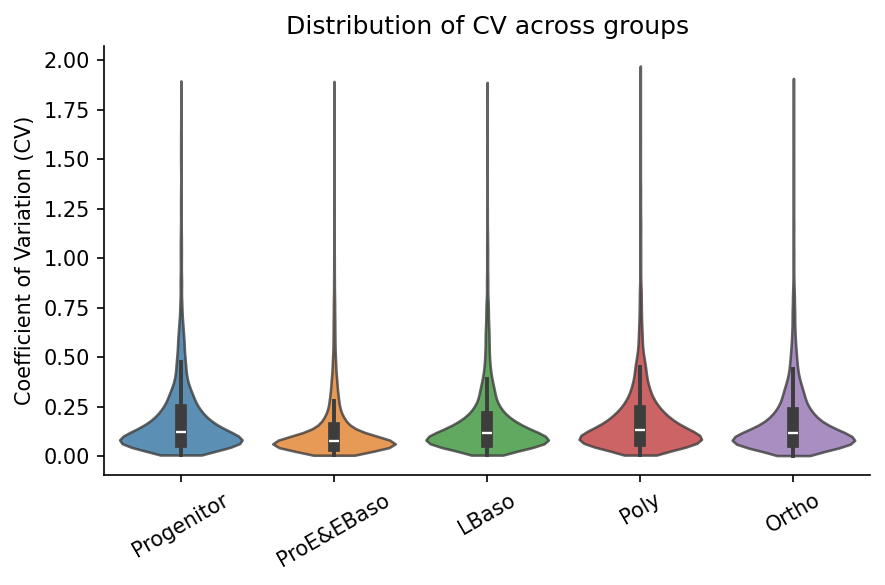

In [18]:
pr.pl.cv_by_group(
    adata,
    group_by="cell_type",
    min_samples=3,
    order=stage_order,
    color_scheme=stage_colors,
    xlabel_rotation=30,
)

**`sample_correlation_matrix`**

Compare sample similarity and inspect whether samples from the same stage cluster together. This implementation requires complete input, so we pass a temporary view of the fully measured, nonconstant proteins selected above. No values are filled and `adata` is unchanged. Correlations therefore describe this shared subset, not all detected proteins. Pearson correlation on raw intensities can be dominated by high-abundance features; dendrograms determine the displayed order. Here the legacy `ax=True` flag returns the heatmap Axes so we can move its legend.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.sample_correlation_matrix.html)


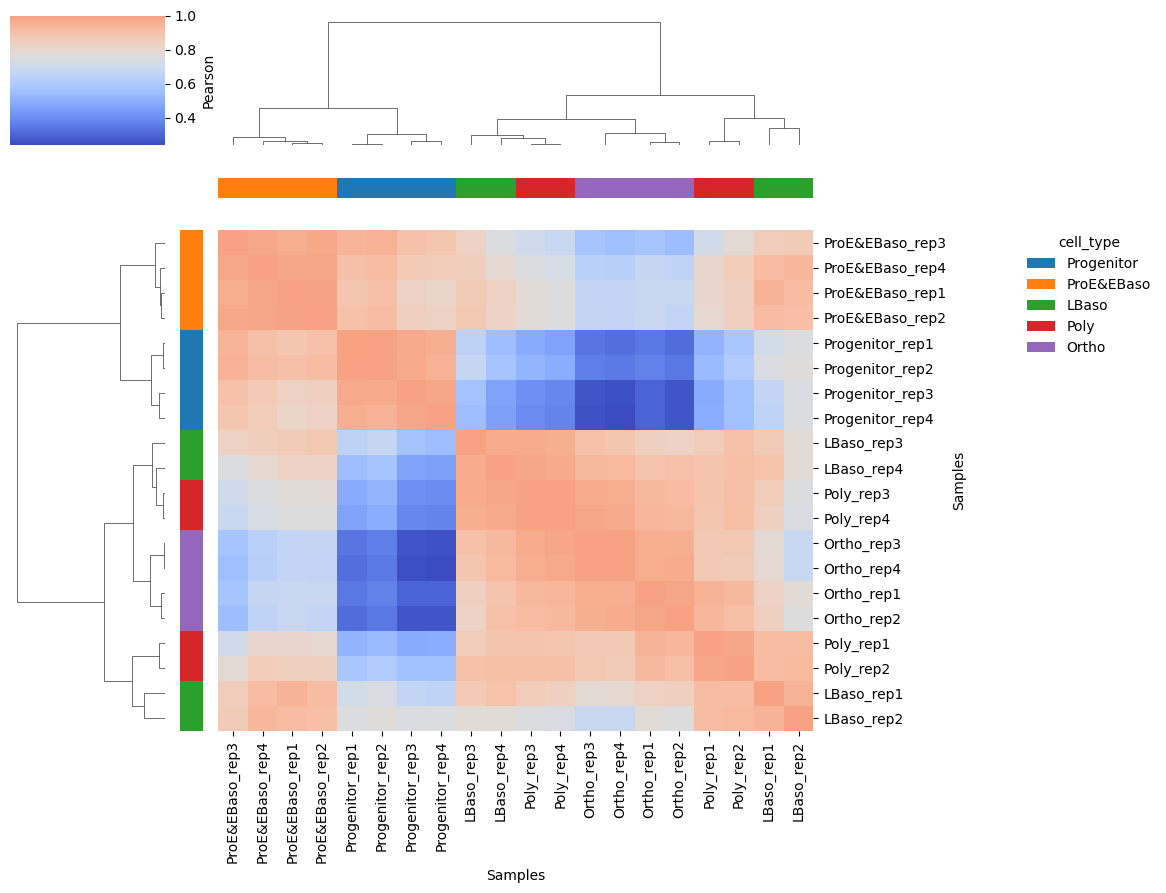

In [19]:
correlation_ax = pr.pl.sample_correlation_matrix(
    adata[:, complete_protein_ids].copy(),
    method="pearson",
    margin_color="cell_type",
    color_scheme=stage_colors,
    xticklabels=True,
    yticklabels=True,
    figsize=(10, 9),
    ax=True,
    show=False,
)

# Move the stage legend clear of the sample labels.
correlation_ax.get_legend().set_bbox_to_anchor((1.35, 1.0))
plt.show()

**`binary_heatmap`**

Inspect detection patterns rather than abundance. For this plot only, `fill_na=0` encodes missing measurements as absent and `threshold=0` encodes positive intensities as present. Consequently, genuine measured zeros and missing values look identical here. `hide_fully_detected=True` focuses the display on incomplete proteins, without filtering `adata`. Thousands of rows form an overview; individual protein labels are hidden.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.binary_heatmap.html)


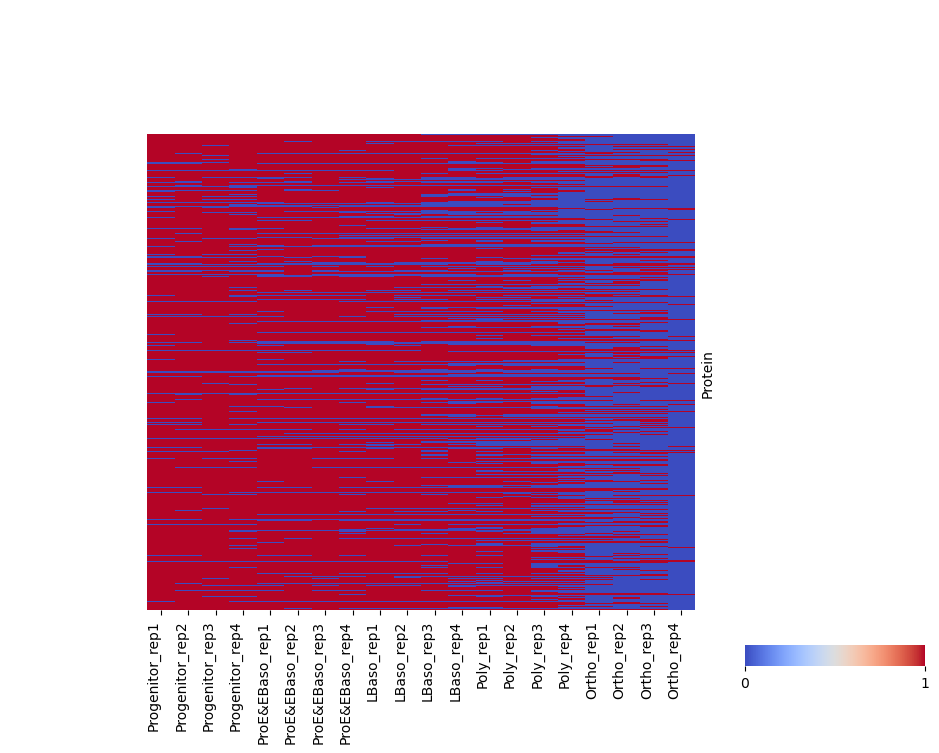

<Axes: ylabel='Protein'>

In [20]:
pr.pl.binary_heatmap(
    adata,
    fill_na=0,
    threshold=0,
    hide_fully_detected=True,
    order_by="cell_type",
    order=stage_order,
    var_id_key="protein_id",
    figsize=(10, 7),
)

**`hclustv_profiles_heatmap`**

Compare relative abundance profiles across stages. Display up to 50 fully measured, nonconstant proteins, chosen in lexicographic protein-ID order for a small reproducible example. These are not the most variable or significant proteins. The function computes per-stage medians, then standardizes each protein profile internally. Colors show relative within-protein variation, not comparable absolute abundances.

Row clustering groups similar profiles. Column clustering is disabled so the explicit developmental sequence remains visible. This plot computes its own profiles; no stored clustering results are required. The complete-protein selection avoids missing-value filling inside the heatmap.

[API reference](https://proteopy.readthedocs.io/en/latest/api/generated/proteopy.pl.hclustv_profiles_heatmap.html)


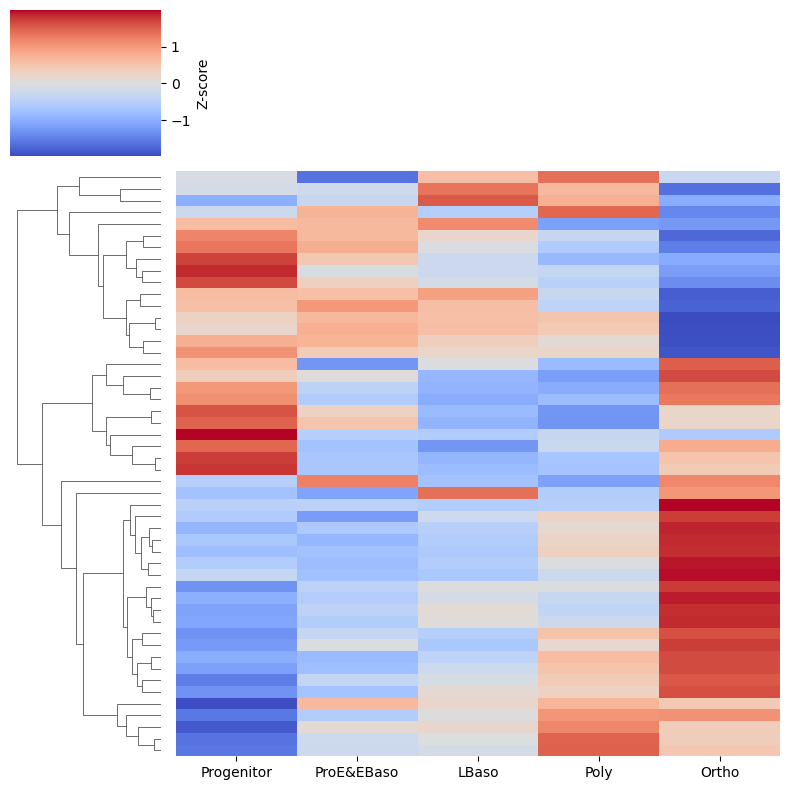

In [21]:
pr.pl.hclustv_profiles_heatmap(
    adata,
    selected_vars=complete_protein_ids[:50],
    group_by="cell_type",
    summary_method="median",
    order=stage_order,
    row_cluster=True,
    col_cluster=False,
    figsize=(8, 8),
)

**The loaded intensities remain unchanged**

All transformations and selections above were for plotting. This check
compares both the measurements and their missing-value positions with the
matrix returned by the loader.


In [22]:
np.testing.assert_array_equal(adata.X, raw_intensities)
print("Raw intensities and missing-value positions are unchanged.")

Raw intensities and missing-value positions are unchanged.


**Other plotting functions**

The [plotting API](https://proteopy.readthedocs.io/en/latest/api/pl.html)
also includes `volcano` and `differential_abundance_box` for differential
analysis results, and `hclustv_silhouette`, `hclustv_elbow`, and
`hclustv_profile_intensities` for stored clustering results. They require
analysis steps beyond this raw-data overview.

Peptide counts, peptide/proteoform intensity profiles, sequence coverage,
and COPF score plots require peptide-level data or proteoform annotations.
They are reserved for the next installment.

## Peptide level

To be developed in a future installment.
